In [11]:
from matplotlib import pyplot as plt
import pandas as pd

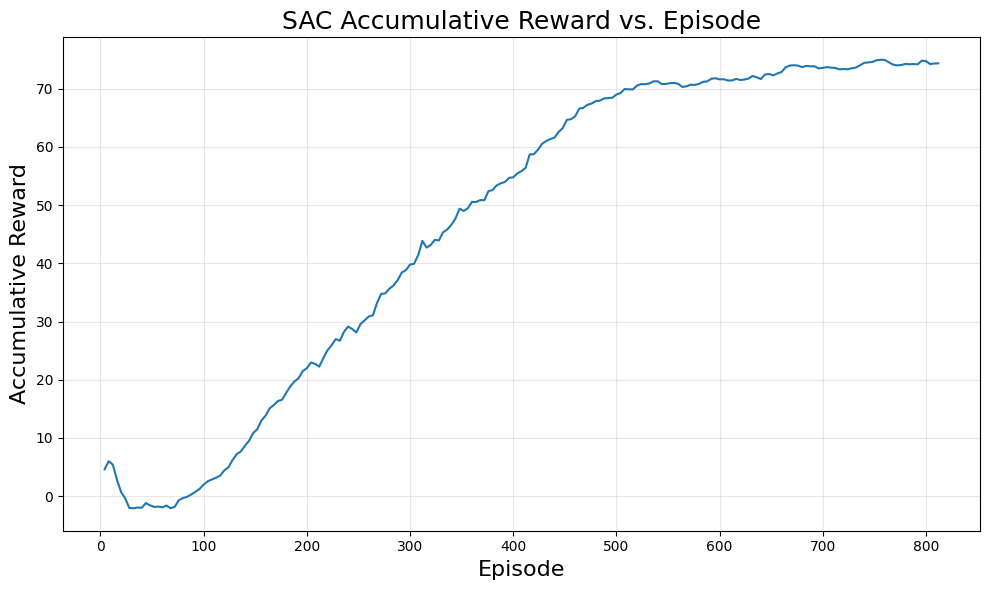

In [13]:
data = pd.read_csv('SAC_10_rewards.csv')
data.drop(columns=['Wall time'], inplace=True)
data['Step'] = data['Step'].astype(int) / 100

data.to_csv('SAC_10_rewards_processed.csv', index=False)

plt.figure(figsize=(10, 6))
plt.plot(data['Step'], data['Value'], label='SAC Reward')
plt.xlabel('Episode', fontsize=16)
plt.ylabel('Accumulative Reward', fontsize=16)
plt.title('SAC Accumulative Reward vs. Episode', fontsize=18)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('SAC_10_rewards_plot.png', dpi=300)
plt.show()


Plot saved to 'evaluation_secrecy_vs_eve_dist.png'


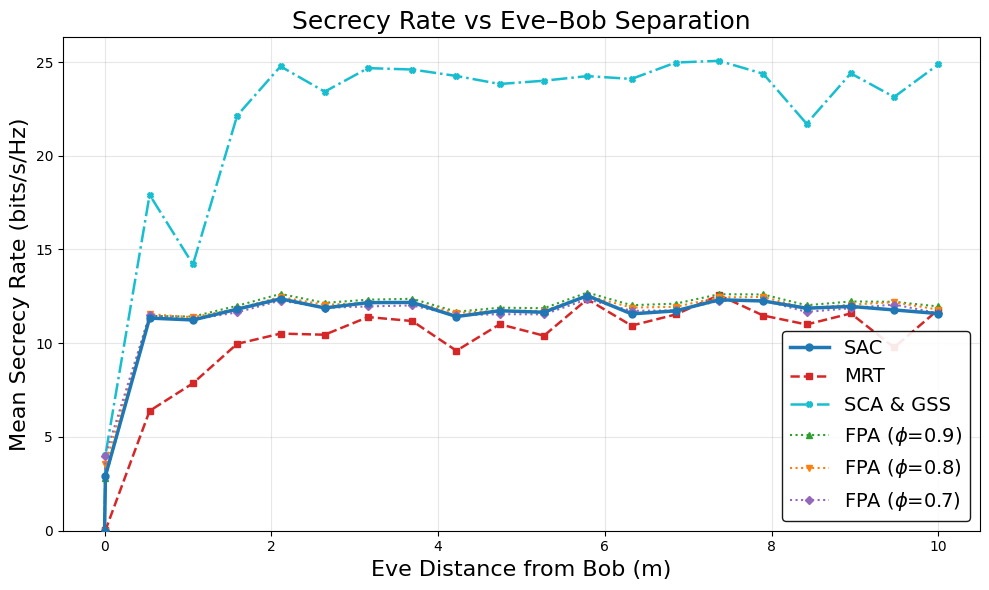

In [17]:
results = pd.read_csv('../evaluation_data.csv')
distances = results['Distance'].values
results = results.drop(columns=['Distance'])

fig, ax = plt.subplots(figsize=(10, 6))

styles = {
    'SAC':                       dict(color='tab:blue',   lw=2.5, ls='-',  marker='o', ms=5, zorder=5),
    'MRT':                       dict(color='tab:red',    lw=1.8, ls='--', marker='s', ms=4),
    'Convex':                    dict(color='tab:cyan',   lw=1.8, ls='-.', marker='X', ms=4),
    r'FPA ($\phi$=0.9)':         dict(color='tab:green',  lw=1.5, ls=':',  marker='^', ms=4),
    r'FPA ($\phi$=0.8)':         dict(color='tab:orange', lw=1.5, ls=':',  marker='v', ms=4),
    r'FPA ($\phi$=0.7)':         dict(color='tab:purple', lw=1.5, ls=':',  marker='D', ms=4),
}

for label, values in results.items():
    legend = label.replace('Convex', 'SCA & GSS')
    ax.plot(distances, values, label=legend, **styles[label])

ax.set_xlabel("Eve Distance from Bob (m)", fontsize=16)
ax.set_ylabel("Mean Secrecy Rate (bits/s/Hz)", fontsize=16)
ax.set_title("Secrecy Rate vs Eve–Bob Separation", fontsize=18)
ax.legend(fontsize=14, loc='lower right', framealpha=0.9, edgecolor='black')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

fig.tight_layout()
out_path = 'evaluation_secrecy_vs_eve_dist.png'
fig.savefig(out_path, dpi=150)
print(f"\nPlot saved to '{out_path}'")
plt.show()